# Centralized analysis

📂 Searching for results in: /home/amoleri/PycharmProjects/FederatedFactory/src/../output/centralized_experiments
Processing medmnist:pathmnist (5 seeds found)...
Processing fed_isic2019 (5 seeds found)...
Processing medmnist:bloodmnist (5 seeds found)...
Processing medmnist:retinamnist (5 seeds found)...
Processing cifar (5 seeds found)...
Processing fed_camelyon16 (5 seeds found)...

✅ Successfully parsed 30 experimental runs.
### 📊 Centralized Experimental Results (Mean ± Std Dev %)


,Accuracy,AUROC,F1,Precision,Recall,Completed Seeds
Dataset,,,,,,
cifar,94.69 ± 0.33,99.75 ± 0.03,94.69 ± 0.33,94.69 ± 0.33,94.69 ± 0.33,5
fed_camelyon16,82.10 ± 0.42,90.64 ± 0.86,78.88 ± 0.62,96.14 ± 0.35,66.88 ± 0.92,5
fed_isic2019,70.38 ± 0.69,90.37 ± 0.74,52.92 ± 1.22,59.21 ± 1.57,49.76 ± 1.26,5
medmnist:bloodmnist,91.23 ± 0.87,99.18 ± 0.13,89.94 ± 1.16,90.88 ± 1.14,89.73 ± 1.30,5
medmnist:pathmnist,84.82 ± 0.81,96.96 ± 0.40,80.50 ± 0.88,83.83 ± 0.64,79.43 ± 0.83,5
medmnist:retinamnist,47.20 ± 0.78,69.69 ± 1.00,33.07 ± 1.73,34.36 ± 2.36,33.16 ± 1.27,5



📝 Table saved to 'centralized_results_table.csv'


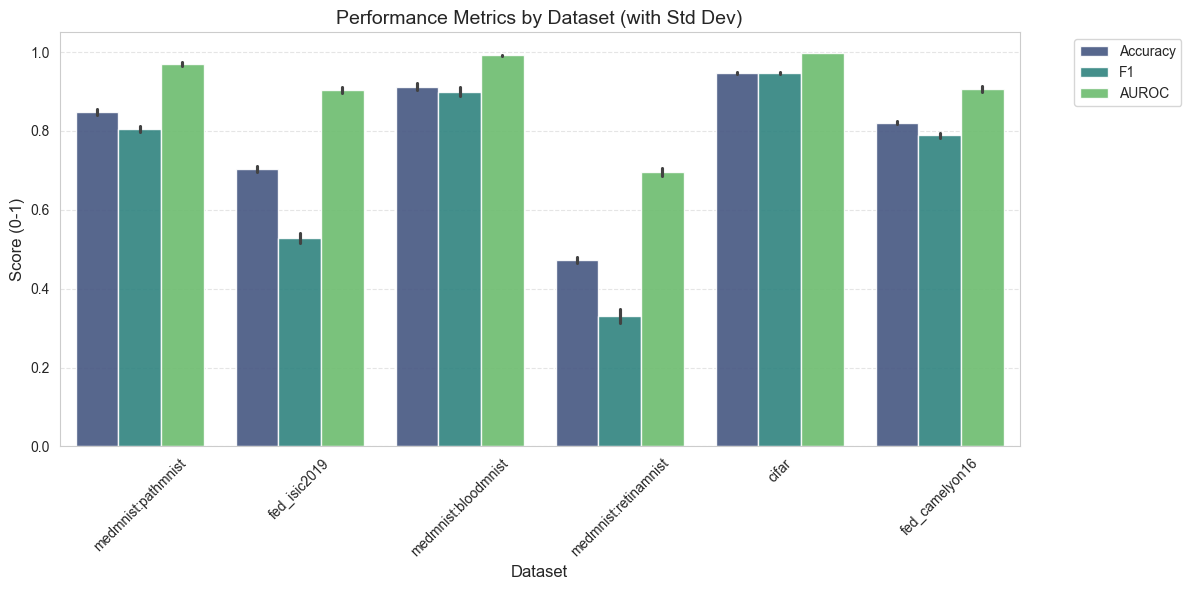

In [18]:
"""
📊 Experimental Results Analysis Module
---------------------------------------

This cell orchestrates the retrieval, aggregation, and statistical analysis of
centralized experimental results. It parses output directories generated by
associated training scripts to compute performance metrics across multiple
random seeds.

🧠 Purpose:
    To validate experimental hypotheses by quantifying model performance stability
    and generalisation capabilities through rigorous statistical aggregation
    (Mean ± Standard Deviation).

🔧 Core Functionalities:
    • Automated directory traversal for multi-dataset and multi-seed experiments
    • Calculation of scalar classification metrics (Accuracy, F1, Precision, Recall)
    • Computation of Area Under the Receiver Operating Characteristic Curve (AUROC)
    • Aggregation of results into publication-ready tabular formats
    • Visualization of performance distributions using error-bar plots

🎯 Intended Use:
    • Post-experiment analysis in academic research pipelines
    • Generation of LaTeX-compatible results tables
    • Quality assurance checks for batch training jobs

📁 Dependencies:
    • os, glob, pathlib (Filesystem navigation)
    • numpy, pandas (Data manipulation and aggregation)
    • sklearn.metrics (Statistical scoring)
    • matplotlib, seaborn (Data visualisation)

📝 Notes:
    The module assumes a specific directory hierarchy:
    `output/centralized_experiments/{dataset}/{model}/seed_{n}`.
    Missing or incomplete runs are handled gracefully via try-catch blocks.

Author: Andrea Moleri
Last Modified: 09/12/2025
"""

# %% [markdown]
# # Experimental Results Analysis
# This notebook parses the results from `run_centralized_baselines`, aggregates metrics across seeds, and generates a publication-ready table with error bars.

# %%
import os
import glob
import json
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

# Suppress UndefinedMetricWarning to prevent verbose logs during aggregation
# This commonly occurs in zero-division scenarios (e.g., extremely imbalanced batches).
warnings.filterwarnings('ignore')

# %% [markdown]
# ## 1. Configuration & Robustness Setup
# We define the root path and the list of metrics we want to calculate.

# %%
# AUTO-DETECT PROJECT ROOT
# Establishes the working context relative to the script execution path.
# Adjust `Path.cwd().parent` if this script is moved to a subdirectory (e.g., `src/analysis`).
PROJECT_ROOT = Path.cwd()

# Define the absolute path to the experimental output directory.
# Expected structure conforms to the bash script logic:
# "$PROJECT_ROOT/output/centralized_experiments/${DATASET}/resnet50/seed_${SEED}"
BASE_OUTPUT_DIR = PROJECT_ROOT / "../output" / "centralized_experiments"

print(f"📂 Searching for results in: {BASE_OUTPUT_DIR}")

# Enforce directory existence to prevent silent failures during file traversal.
if not BASE_OUTPUT_DIR.exists():
    raise FileNotFoundError(f"Could not find output directory: {BASE_OUTPUT_DIR}. Are you running this from the Project Root?")

# %% [markdown]
# ## 2. Metric Calculation Logic
# This function loads the `npz` files (Predicted Probabilities and Ground Truth) to calculate complex metrics that weren't stored in the simple JSON logs.

# %%
def calculate_metrics_from_npz(npz_path):
    """
    Computes a comprehensive suite of classification metrics from stored prediction arrays.

    This function loads ground truth labels and predicted probabilities from a compressed
    NumPy archive (.npz), handling both binary and multi-class classification scenarios.



[Image of ROC curve]


    Parameters
    ----------
    npz_path : pathlib.Path or str
        The file path to the `predictions.npz` archive containing:
        - 'y_true': Ground truth labels.
        - 'y_pred': Hard predicted class labels.
        - 'y_probs': Probability estimates (soft predictions).

    Returns
    -------
    dict
        A dictionary containing scalar metric values:
        - 'Accuracy': Proportion of correct predictions.
        - 'AUROC': Area Under the Receiver Operating Characteristic Curve.
        - 'F1': Harmonic mean of precision and recall.
        - 'Precision': The ratio $tp / (tp + fp)$.
        - 'Recall': The ratio $tp / (tp + fn)$.
    None
        Returned if the file cannot be processed (e.g., corruption or I/O error).

    Exceptions
    ----------
    ValueError
        implicitly handled via try/except block during AUROC calculation for edge cases
        (e.g., missing classes in a specific split).
    """
    try:
        data = np.load(npz_path)
        y_true = data['y_true']
        y_pred = data['y_pred']
        y_probs = data['y_probs']

        # Determine the dimensionality of the probability matrix to infer classification type.
        # - Binary: Shape [N, 2]
        # - Multi-class: Shape [N, C] where C > 2
        num_classes = y_probs.shape[1]
        average_strategy = 'binary' if num_classes == 2 else 'macro'

        # 1. Accuracy
        # Simple ratio of correct predictions to total samples.
        acc = accuracy_score(y_true, y_pred)

        # 2. Precision, Recall, F1
        # 'macro' averaging calculates metrics for each label and finds their unweighted mean.
        # This effectively treats all classes equally, penalising poor performance on minority classes.
        prec = precision_score(y_true, y_pred, average=average_strategy, zero_division=0)
        rec = recall_score(y_true, y_pred, average=average_strategy, zero_division=0)
        f1 = f1_score(y_true, y_pred, average=average_strategy, zero_division=0)

        # 3. AUROC (Area Under Receiver Operating Characteristic)
        try:
            if num_classes == 2:
                # For binary classification, roc_auc_score typically expects the probability
                # of the positive class (column index 1).
                auroc = roc_auc_score(y_true, y_probs[:, 1])
            else:
                # For multi-class, we employ the One-vs-Rest (OvR) strategy with macro averaging.
                auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except ValueError:
            # Fallback for edge cases where a batch lacks instances of a specific class,
            # rendering AUROC undefined for that specific run.
            auroc = np.nan

        return {
            "Accuracy": acc,
            "AUROC": auroc,
            "F1": f1,
            "Precision": prec,
            "Recall": rec
        }

    except Exception as e:
        print(f"⚠️ Error processing {npz_path.name}: {e}")
        return None

# %% [markdown]
# ## 3. Data Parsing
# We walk through the directory structure. The parser is error-tolerant: if a seed failed, it simply skips it without crashing the whole notebook.

# %%
records = []

# Traverse the filesystem to locate experiment results.
# Iterates through dataset directories located within `output/centralized_experiments`.
for dataset_path in BASE_OUTPUT_DIR.iterdir():
    if not dataset_path.is_dir():
        continue

    dataset_name = dataset_path.name

    # Validate the existence of the specific model architecture folder (ResNet50).
    model_path = dataset_path / "resnet50"
    if not model_path.exists():
        continue

    # Identify all subdirectories corresponding to individual random seeds (e.g., 'seed_1').
    seed_folders = list(model_path.glob("seed_*"))

    if not seed_folders:
        print(f"⚠️ Dataset found ({dataset_name}) but no seed folders present.")
        continue

    print(f"Processing {dataset_name} ({len(seed_folders)} seeds found)...")

    for seed_dir in seed_folders:
        # Extract the integer seed value from the directory name string.
        seed_val = seed_dir.name.split('_')[-1]

        # Construct path to the NumPy archive containing prediction data.
        npz_file = seed_dir / "predictions.npz"

        if not npz_file.exists():
            # Gracefully skip incomplete runs where the output file was not generated.
            print(f"  ❌ Skipping Seed {seed_val}: predictions.npz not found (Run likely crashed/incomplete).")
            continue

        # Compute performance metrics for this specific seed.
        metrics = calculate_metrics_from_npz(npz_file)

        if metrics:
            metrics['Dataset'] = dataset_name
            metrics['Seed'] = int(seed_val)
            records.append(metrics)

# Instantiate a Pandas DataFrame to facilitate tabular aggregation.
df = pd.DataFrame(records)

if df.empty:
    print("\n❌ No valid results found! Check your paths.")
else:
    print(f"\n✅ Successfully parsed {len(df)} experimental runs.")

# %% [markdown]
# ## 4. Results Aggregation
# We group by dataset and calculate the Mean and Standard Deviation.

# %%
if not df.empty:
    # Group results by 'Dataset' to aggregate across different random seeds.
    grouped = df.groupby('Dataset')[['Accuracy', 'AUROC', 'F1', 'Precision', 'Recall']]

    # Compute descriptive statistics (Mean and Standard Deviation).
    means = grouped.mean()
    stds = grouped.std()

    # Count valid runs to verify statistical significance/completeness.
    counts = grouped.count()

    # Initialise a new DataFrame to store string-formatted results ("Mean ± Std").
    formatted_df = pd.DataFrame()

    metrics_cols = ['Accuracy', 'AUROC', 'F1', 'Precision', 'Recall']

    for col in metrics_cols:
        # Scale metrics to percentages (0-100) for improved readability in tables.
        m = means[col] * 100
        s = stds[col] * 100

        # format: "XX.XX ± YY.YY"
        formatted_df[col] = m.map('{:.2f}'.format) + " ± " + s.map('{:.2f}'.format)

    # Append the count of completed seeds to the summary table for validation.
    formatted_df['Completed Seeds'] = counts['Accuracy']

    print("### 📊 Centralized Experimental Results (Mean ± Std Dev %)")
    display(formatted_df)

    # Serialise the formatted table to CSV for inclusion in LaTeX documents or reports.
    formatted_df.to_csv("centralized_results_table.csv")
    print("\n📝 Table saved to 'centralized_results_table.csv'")

# %% [markdown]
# ## 5. Visualizing Stability
# A quick boxplot to visualize the variance across seeds.

# %%
import matplotlib.pyplot as plt
import seaborn as sns

if not df.empty:
    plt.figure(figsize=(12, 6))

    # Transform DataFrame from wide format to long format for Seaborn compatibility.
    # This stacks metrics into a single column, allowing 'hue' based separation.
    df_melted = df.melt(id_vars=['Dataset', 'Seed'],
                        value_vars=['Accuracy', 'F1', 'AUROC'],
                        var_name='Metric', value_name='Score')

    # Generate a bar plot with error bars representing the standard deviation.
    sns.barplot(data=df_melted, x='Dataset', y='Score', hue='Metric', errorbar='sd', palette='viridis', alpha=0.9)

    plt.title("Performance Metrics by Dataset (with Std Dev)", fontsize=14)
    plt.xlabel("Dataset", fontsize=12)
    plt.ylabel("Score (0-1)", fontsize=12)
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    # Position the legend outside the plot area to prevent data occlusion.
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

📂 Project Root: /home/amoleri/PycharmProjects/FederatedFactory
📂 Search Dir:   /home/amoleri/PycharmProjects/FederatedFactory/output/main_experiments
🚀 Found 160 prediction files. Parsing...
✅ Successfully parsed 160 runs.


,Partition,Dataset,Model,Alpha,Seed,Accuracy,F1,AUROC,learning_rate,fedprox_mu,feddyn_alpha,baseline_momentum,Params_Display,Full_Model_ID
0,dirichlet,medmnist:bloodmnist,scaffold,0.1,1,0.781643,0.735106,0.961841,0.1,0.01,0.01,0.0,"lr=0.1, mom=0.0","scaffold (lr=0.1, mom=0.0)"
1,dirichlet,medmnist:bloodmnist,scaffold,0.1,5,0.845951,0.796168,0.977057,0.1,0.01,0.01,0.0,"lr=0.1, mom=0.0","scaffold (lr=0.1, mom=0.0)"
2,dirichlet,medmnist:bloodmnist,scaffold,0.1,3,0.846828,0.820636,0.979653,0.1,0.01,0.01,0.0,"lr=0.1, mom=0.0","scaffold (lr=0.1, mom=0.0)"



📊 Main Leaderboard:


Accuracy  \
Partition Dataset              Model    Params_Display       Alpha                    
dirichlet cifar                fedavg   lr=0.1               0.1     89.76% ± 1.12%   
                               feddyn   lr=0.1, dyn_α=0.0001 0.1    61.82% ± 11.47%   
                               fedprox  lr=0.1, μ=0.001      0.1     89.67% ± 1.15%   
                               scaffold lr=0.1, mom=0.0      0.1     79.26% ± 5.10%   
          fed_isic2019         fedavg   lr=0.1               0.1     60.35% ± 6.94%   
                               feddyn   lr=0.1, dyn_α=0.001  0.1     53.63% ± 5.48%   
                               fedprox  lr=0.1, μ=0.01       0.1     62.83% ± 2.41%   
                               scaffold lr=0.1, mom=0.0      0.1     50.03% ± 1.75%   
          medmnist:bloodmnist  fedavg   lr=0.1               0.1     83.46% ± 5.18%   
                               feddyn   lr=0.1, dyn_α=0.0001 0.1     64.93% ± 8.63%   
                               fedprox  lr=0.1, μ=0.001      0.1     84.11% ± 5.38%   
                               scaffold lr=0.1, mom=0.0      0.1     82.31% ± 2.97%   
          medmnist:retinamnist fedavg   lr=0.1               0.1     45.20% ± 3.80%   
                               feddyn   lr=0.1, dyn_α=0.0001 0.1     45.25% ± 3.91%   
                               fedprox  lr=0.1, μ=0.1        0.1     45.45% ± 4.36%   
                               scaffold lr=0.1, mom=0.0      0.1     43.50% ± 0.00%   
silos     cifar                fedavg   lr=0.1               N/A     11.36% ± 1.28%   
                               feddyn   lr=0.1, dyn_α=0.001  N/A     10.12% ± 0.24%   
                               fedprox  lr=0.1, μ=0.01       N/A     18.08% ± 1.18%   
                               scaffold lr=0.1, mom=0.0      N/A     12.99% ± 0.75%   
          fed_isic2019         fedavg   lr=0.1               N/A     48.22% ± 0.00%   
                               feddyn   lr=0.1, dyn_α=0.001  N/A     48.22% ± 0.00%   
                               fedprox  lr=0.1, μ=0.1        N/A     48.22% ± 0.00%   
                               scaffold lr=0.1, mom=0.0      N/A     48.22% ± 0.00%   
          medmnist:bloodmnist  fedavg   lr=0.1               N/A     21.88% ± 5.39%   
                               feddyn   lr=0.1, dyn_α=0.001  N/A     19.47% ± 0.00%   
                               fedprox  lr=0.1, μ=0.1        N/A     20.18% ± 1.57%   
                               scaffold lr=0.1, mom=0.0      N/A     22.60% ± 1.96%   
          medmnist:retinamnist fedavg   lr=0.1               N/A     43.50% ± 0.00%   
                               feddyn   lr=0.1, dyn_α=0.0001 N/A     43.50% ± 0.00%   
                               fedprox  lr=0.1, μ=0.001      N/A     43.50% ± 0.00%   
                               scaffold lr=0.1, mom=0.9      N/A     43.50% ± 0.00%   

                                                                              AUROC  \
Partition Dataset              Model    Params_Display       Alpha                    
dirichlet cifar                fedavg   lr=0.1               0.1    0.9922 ± 0.0019   
                               feddyn   lr=0.1, dyn_α=0.0001 0.1    0.9487 ± 0.0265   
                               fedprox  lr=0.1, μ=0.001      0.1    0.9921 ± 0.0019   
                               scaffold lr=0.1, mom=0.0      0.1    0.9773 ± 0.0086   
          fed_isic2019         fedavg   lr=0.1               0.1    0.7673 ± 0.1233   
                               feddyn   lr=0.1, dyn_α=0.001  0.1    0.6848 ± 0.0781   
                               fedprox  lr=0.1, μ=0.01       0.1    0.8321 ± 0.0160   
                               scaffold lr=0.1, mom=0.0      0.1    0.6437 ± 0.0619   
          medmnist:bloodmnist  fedavg   lr=0.1               0.1    0.9757 ± 0.0111   
                               feddyn   lr=0.1, dyn_α=0.0001 0.1    0.9202 ± 0.0221   
                               fedprox  lr=0.1, μ=0.001      0.1    0.97


💾 Saved results to: /home/amoleri/PycharmProjects/FederatedFactory/federated_baselines_results.csv


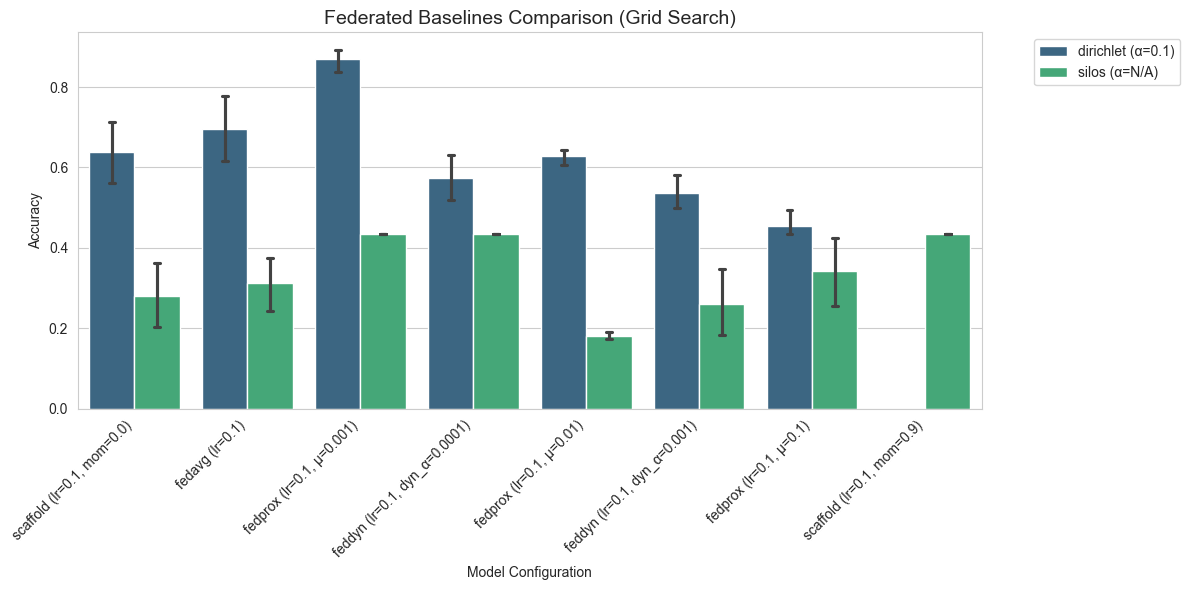

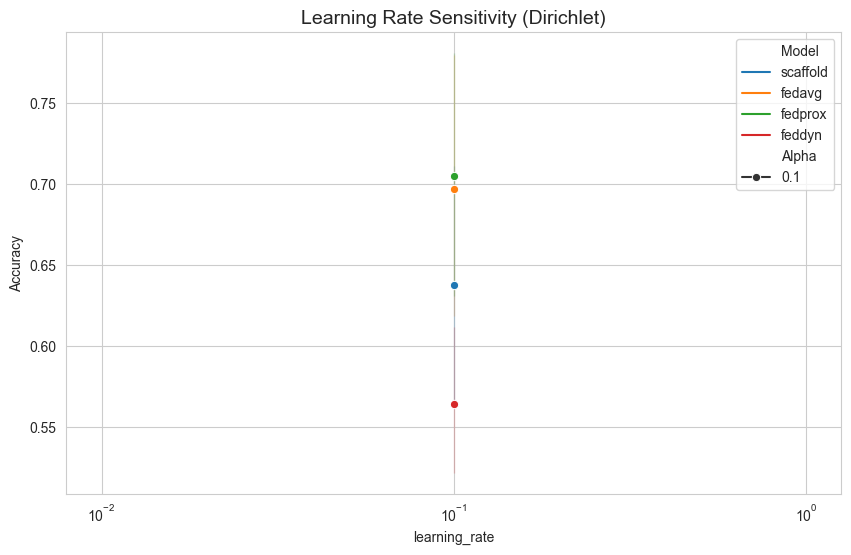

In [21]:
# %% [markdown]
# # 📊 Federated Experiments Analysis (Robust)
#
# This notebook parses the specific directory structure generated by `run_federated_baselines.sh`.
# It handles both `dirichlet` and `silos` partitions and extracts grid search hyperparameters.

# %%
import os
import json
import re
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Suppress warnings
warnings.filterwarnings('ignore')

# %% [markdown]
# ## 1. Configuration & Setup

# %%
# Auto-detect project root
current_path = Path.cwd()
if (current_path / "src").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "src").exists():
    PROJECT_ROOT = current_path.parent
else:
    # Adjust this if your notebook is deeper in the folder structure
    PROJECT_ROOT = Path("../")

# Matches the bash script: $PROJECT_ROOT/output/main_experiments
BASE_OUTPUT_DIR = PROJECT_ROOT / "output" / "main_experiments"

print(f"📂 Project Root: {PROJECT_ROOT.resolve()}")
print(f"📂 Search Dir:   {BASE_OUTPUT_DIR.resolve()}")

if not BASE_OUTPUT_DIR.exists():
    print(f"❌ Error: {BASE_OUTPUT_DIR} not found. Did the bash script run?")

# Specific hyperparameters we want to extract from args.json if they exist
# These match the grid search in your bash script
GRID_PARAMS = [
    'learning_rate',
    'fedprox_mu',
    'feddyn_alpha',
    'baseline_momentum'
]

# %% [markdown]
# ## 2. Metrics & Parsing Utilities

# %%
def load_json(path):
    try:
        with open(path, 'r') as f:
            return json.load(f)
    except:
        return {}

def calculate_metrics(npz_path):
    """
    Loads predictions.npz and calculates scalar metrics.
    """
    try:
        data = np.load(npz_path, allow_pickle=True)

        # Check for required keys
        if 'y_true' not in data or 'y_pred' not in data:
            return None

        y_true = data['y_true']
        y_pred = data['y_pred']

        # Optional: Probabilities
        y_probs = data['y_probs'] if 'y_probs' in data else None

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

        auroc = np.nan
        if y_probs is not None:
            try:
                # Handle binary vs multiclass shapes
                if len(y_probs.shape) > 1 and y_probs.shape[1] > 2:
                    auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
                else:
                    # Binary case, usually expects 1D array of pos class or column 1
                    p = y_probs[:, 1] if len(y_probs.shape) > 1 else y_probs
                    auroc = roc_auc_score(y_true, p)
            except:
                pass

        return {"Accuracy": acc, "F1": f1, "AUROC": auroc}
    except Exception as e:
        # print(f"⚠️ Error reading {npz_path.name}: {e}")
        return None

def parse_folder_structure(file_path):
    """
    Fallback if args.json is missing.
    Parses: .../baselines_dirichlet/epochs_5/dataset/model_arg_suffix/...
    """
    parts = file_path.parts
    meta = {}

    # Identify partition type
    if "baselines_dirichlet" in parts:
        meta['partition'] = "dirichlet"
    elif "baselines_silos" in parts:
        meta['partition'] = "silos"

    # Try to extract seed
    for part in parts:
        if part.startswith("seed_"):
            meta['seed'] = int(part.replace("seed_", ""))
        if part.startswith("alpha_"):
            meta['alpha'] = float(part.replace("alpha_", ""))

    return meta

# %% [markdown]
# ## 3. Execution Crawler

# %%
records = []
files = list(BASE_OUTPUT_DIR.rglob("predictions.npz"))

print(f"🚀 Found {len(files)} prediction files. Parsing...")

for file_path in files:
    # 1. Attempt to find args.json
    # It might be in the same dir as predictions.npz, or one level up
    args = {}
    args_path = file_path.parent / "args.json"
    if not args_path.exists():
        args_path = file_path.parent.parent / "args.json"

    if args_path.exists():
        args = load_json(args_path)

    # 2. Get structural metadata (fallback or supplement)
    struct_meta = parse_folder_structure(file_path)

    # 3. Consolidate Metadata
    # Prefer args.json, fallback to path parsing
    dataset = args.get('dataset', "Unknown")
    model_raw = args.get('model', "Unknown")
    model_clean = model_raw.replace("baseline:", "")

    partition = args.get('partition', struct_meta.get('partition', 'Unknown'))
    seed = args.get('seed', struct_meta.get('seed', 'Unknown'))
    alpha = args.get('alpha', struct_meta.get('alpha', 'N/A'))

    # If using silos, alpha is usually irrelevant/None
    if partition == 'silos':
        alpha = "N/A"

    # 4. Calculate Results
    metrics = calculate_metrics(file_path)

    if metrics:
        entry = {
            "Partition": partition,
            "Dataset": dataset,
            "Model": model_clean,
            "Alpha": alpha,
            "Seed": seed,
            **metrics
        }

        # Add Grid Search Params (LR, Mu, etc.)
        params_str = []
        for p in GRID_PARAMS:
            if p in args:
                val = args[p]
                entry[p] = val
                # Build a display string for charts: e.g. "lr=0.1, mu=0.01"
                # Only add if it's distinct (e.g., FedProx needs mu, FedAvg doesn't)
                if p == 'learning_rate':
                    params_str.append(f"lr={val}")
                elif p == 'fedprox_mu' and 'fedprox' in model_clean:
                    params_str.append(f"μ={val}")
                elif p == 'feddyn_alpha' and 'feddyn' in model_clean:
                    params_str.append(f"dyn_α={val}")
                elif p == 'baseline_momentum' and 'scaffold' in model_clean:
                    params_str.append(f"mom={val}")

        entry['Params_Display'] = ", ".join(params_str)
        entry['Full_Model_ID'] = f"{model_clean} ({entry['Params_Display']})"

        records.append(entry)

df = pd.DataFrame(records)

if df.empty:
    print("❌ No valid run data found.")
else:
    print(f"✅ Successfully parsed {len(df)} runs.")
    display(df.head(3))

# %% [markdown]
# ## 4. Aggregated Results (Grid Search Analysis)

# %%
if not df.empty:
    # We group by the specific settings defined in your Bash arrays
    group_cols = ['Partition', 'Dataset', 'Model', 'Params_Display', 'Alpha']

    # Calculate Mean and Std
    agged = df.groupby(group_cols)[['Accuracy', 'AUROC', 'F1']].agg(['mean', 'std', 'count'])

    # Flatten columns for clean display
    final_view = pd.DataFrame()
    final_view['Accuracy'] = agged[('Accuracy', 'mean')].map('{:.2%}'.format) + " ± " + agged[('Accuracy', 'std')].map('{:.2%}'.format)
    final_view['AUROC'] = agged[('AUROC', 'mean')].map('{:.4f}'.format) + " ± " + agged[('AUROC', 'std')].map('{:.4f}'.format)
    final_view['Samples'] = agged[('Accuracy', 'count')]

    print("\n📊 Main Leaderboard:")
    display(final_view)

    # Save to CSV
    csv_path = PROJECT_ROOT / "federated_baselines_results.csv"
    final_view.to_csv(csv_path)
    print(f"\n💾 Saved results to: {csv_path}")

# %% [markdown]
# ## 5. Visualizations

# %%
if not df.empty:
    # Filter for a specific dataset if you have multiple
    # datasets = df['Dataset'].unique()

    # Plotting Accuracy vs Model Config
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    # We combine Partition and Alpha for the X-axis grouping, or Hue
    df['Setting'] = df['Partition'] + " (α=" + df['Alpha'].astype(str) + ")"

    sns.barplot(
        data=df,
        x='Full_Model_ID',
        y='Accuracy',
        hue='Setting',
        palette='viridis',
        capsize=.1
    )

    plt.title("Federated Baselines Comparison (Grid Search)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Accuracy")
    plt.xlabel("Model Configuration")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 6. Hyperparameter Sensitivity (e.g. Learning Rate)

# %%
if not df.empty and 'learning_rate' in df.columns:
    plt.figure(figsize=(10, 6))

    # Filter for just one dataset/partition to make it readable
    subset = df[df['Partition'] == 'dirichlet']

    if not subset.empty:
        sns.lineplot(
            data=subset,
            x='learning_rate',
            y='Accuracy',
            hue='Model',
            style='Alpha',
            markers=True,
            dashes=False
        )
        plt.xscale('log')
        plt.title("Learning Rate Sensitivity (Dirichlet)", fontsize=14)
        plt.ylabel("Accuracy")
        plt.show()

In [1]:
import os
import json
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score
from warnings import simplefilter

# Ignore undefined metric warnings (e.g. F1 when 0 predictions)
simplefilter(action='ignore', category=UserWarning)

# ==============================================================================
# ⚙️ CONFIGURATION
# ==============================================================================

# Map the shell script logic for Latent Dimensions
def get_latent_dim(dataset_name):
    if "isic" in dataset_name.lower():
        return 64
    return 128

# Define the Experiment Grid
DATASETS = [
    "cifar",
    "medmnist:bloodmnist",
    "medmnist:retinamnist",
    "medmnist:pathmnist",
    "fed_isic2019"
]

# Map logical partitions to folder names generated by experiment_setup.py
# Logic: f"{partition_mode}-{aggregation_display}" if skew/dirichlet else partition_mode
# Shell script uses AGGREGATION="weighted"
PARTITIONS_MAP = {
    "Silos": "silos",
    "Dirichlet (0.1)": "dirichlet-weighted"
}

MODES = ["server", "local"]
SEEDS = [1, 2, 3, 4, 5]

# Root directories where shell scripts dumped outputs
# Ensure these folders exist relative to where you run this notebook
ROOT_DIRS = {
    "H100": Path("FederatedFactory/federatedfactory_output_H100"),
    "L40":  Path("FederatedFactory/federatedfactory_output_L40")
}

# ==============================================================================
# 🧮 METRIC CALCULATOR
# ==============================================================================

def compute_metrics(npz_path, num_classes):
    """Calculates granular metrics from the saved prediction arrays."""
    data = np.load(npz_path, allow_pickle=True)
    y_true = data['y_true']
    y_pred = data['y_pred']
    y_probs = data['y_probs']

    # Accuracy
    acc = accuracy_score(y_true, y_pred) * 100

    # Formatting for sklearn (weighted handles class imbalance better)
    avg_method = 'weighted'

    # Precision / Recall / F1
    prec = precision_score(y_true, y_pred, average=avg_method, zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average=avg_method, zero_division=0) * 100
    f1 = f1_score(y_true, y_pred, average=avg_method, zero_division=0) * 100

    # AUROC
    try:
        if num_classes == 2:
            # Binary case: need probabilities of the positive class
            # Assuming y_probs has shape (N, 2)
            if y_probs.shape[1] == 2:
                auroc = roc_auc_score(y_true, y_probs[:, 1]) * 100
            else:
                auroc = 0.0 # Fallback
        else:
            # Multiclass case: OVR (One-vs-Rest) is standard
            auroc = roc_auc_score(y_true, y_probs, multi_class='ovr', average=avg_method) * 100
    except Exception as e:
        auroc = 0.0 # Fallback if AUROC fails (e.g. only 1 class present in test set)

    return acc, auroc, f1, prec, rec

# ==============================================================================
# 🚀 PARSER LOOP
# ==============================================================================

results = []

print(f"{'Dataset':<25} | {'Part':<15} | {'Mode':<8} | {'Hardware':<5} | {'Seeds':<5} | Status")
print("-" * 90)

# We check both hardware roots to find where the experiment ran
for hardware, root_path in ROOT_DIRS.items():
    if not root_path.exists():
        continue

    for dataset in DATASETS:
        latent_dim = get_latent_dim(dataset)

        for partition_label, partition_folder in PARTITIONS_MAP.items():
            for mode in MODES:

                metrics_buffer = {
                    "acc": [], "auroc": [], "f1": [], "prec": [], "rec": []
                }

                successful_seeds = 0

                for seed in SEEDS:
                    # Construct Path based on experiment_setup.py logic
                    # Structure: output/model/dataset/seed/mode-Ldim/partition/date/time
                    # Note: Model is hardcoded to "diffusion" in the shell scripts

                    # 1. Base Search Path
                    search_pattern = (
                        root_path /
                        "diffusion" /
                        dataset /
                        f"seed-{seed}" /
                        f"{mode}-L{latent_dim}" /
                        partition_folder /
                        "*" / "*" / # Date / Time folders (wildcard)
                        "artifacts" / "predictions.npz"
                    )

                    # 2. Find file (glob because date/time is unknown)
                    found_files = glob.glob(str(search_pattern))

                    if not found_files:
                        continue

                    # Take the most recent run if duplicates exist
                    target_file = Path(found_files[-1])

                    try:
                        # Load args to get class count for AUROC
                        args_path = target_file.parent.parent / "args.json"
                        with open(args_path, 'r') as f:
                            args_data = json.load(f)

                        # Detect num classes (fallback to 10 if not found, though usually safe)
                        # We can infer from predictions.npz shapes too
                        tmp_data = np.load(target_file)
                        n_classes = tmp_data['y_probs'].shape[1]

                        # Compute
                        acc, auroc, f1, prec, rec = compute_metrics(target_file, n_classes)

                        metrics_buffer["acc"].append(acc)
                        metrics_buffer["auroc"].append(auroc)
                        metrics_buffer["f1"].append(f1)
                        metrics_buffer["prec"].append(prec)
                        metrics_buffer["rec"].append(rec)
                        successful_seeds += 1

                    except Exception as e:
                        # Corrupt file or incomplete write
                        continue

                # Prepare Result Row
                if successful_seeds > 0:
                    row = {
                        "Dataset": dataset,
                        "Hardware": hardware,
                        "Partition": partition_label,
                        "Mode": mode.capitalize(),
                        "N_Seeds": successful_seeds
                    }

                    # Format: "Mean ± Std"
                    for m_name, vals in metrics_buffer.items():
                        mean = np.mean(vals)
                        std = np.std(vals)
                        row[m_name] = f"{mean:.2f} ± {std:.2f}"
                        # Store raw mean for sorting if needed
                        row[f"{m_name}_raw"] = mean

                    results.append(row)
                    print(f"{dataset:<25} | {partition_label:<15} | {mode:<8} | {hardware:<5} | {successful_seeds}/5   | ✅ Done")
                else:
                    # Optional: Print missing
                    pass

# ==============================================================================
# 📊 DATAFRAME FORMATTING
# ==============================================================================

if results:
    df = pd.DataFrame(results)

    # Sort for readability
    df = df.sort_values(by=["Dataset", "Partition", "Mode"])

    # Reorder columns
    cols = [
        "Dataset", "Partition", "Mode", "N_Seeds",
        "acc", "auroc", "f1", "prec", "rec"
    ]

    # Rename for final table
    rename_map = {
        "acc": "Test Acc (%)",
        "auroc": "AUROC (%)",
        "f1": "F1 Score (%)",
        "prec": "Precision (%)",
        "rec": "Recall (%)"
    }

    final_table = df[cols].rename(columns=rename_map)

    # Display Style (Jupyter)
    from IPython.display import display

    # Set pandas display options to ensure full table visibility
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)

    print("\n" + "="*80)
    print("🔬 FEDERATED FACTORY EXPERIMENTAL RESULTS")
    print("="*80)
    display(final_table)

    # Optional: Save to CSV
    final_table.to_csv("federated_factory_results.csv", index=False)
    print("\nSaved detailed results to 'federated_factory_results.csv'")

else:
    print("\n⚠️ No completed experiments found. Check paths and ensure 'artifacts/predictions.npz' exists.")

Dataset                   | Part            | Mode     | Hardware | Seeds | Status
------------------------------------------------------------------------------------------

⚠️ No completed experiments found. Check paths and ensure 'artifacts/predictions.npz' exists.
